# Training application model

In [2]:
import pandas as pd
import numpy as np

from pathlib import Path
from anomaly_detection.parser.data_parsers import parse_application
from anomaly_detection.transformers import application_transformer

c:\Users\hp\AppData\Local\pypoetry\Cache\virtualenvs\anomaly-detection-mxkT3iGB-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Path to the data
project_folder = Path.cwd().parent

output_path = project_folder / "data/training/application"

application_evtx_path = project_folder / "data/raw/93_applog.evtx"

application_evtx_path

WindowsPath('c:/Users/hp/Documents/School/anomaly-detection/data/raw/93_applog.evtx')

# Data preparation

In [4]:
application_training_records = parse_application(application_evtx_path)

application_training_records[0]

{'EventRecordID': 2899035,
 'timestamp': {'hour_sin': np.float64(0.49999999999999994),
  'minute_cos': np.float64(0.913545457642601),
  'day_sin': np.float64(-0.433883739117558),
  'day_cos': np.float64(-0.9009688679024191),
  'month_sin': np.float64(1.2246467991473532e-16),
  'minute_sin': np.float64(-0.40673664307580015),
  'second_cos': np.float64(1.0),
  'hour_cos': np.float64(-0.8660254037844387),
  'deltatime': Timedelta('0 days 00:00:20.289018'),
  'month_cos': np.float64(-1.0),
  'second_sin': np.float64(0.0)},
 'profile': {'event_id_frequency': np.float64(0.9653113448962184),
  'version': None,
  'execution_thread_id': None,
  'event_record_id': 2899035,
  'correlation_activity_id': None,
  'previous_event_id': 4,
  'event_id': 4},
 'data': {'entity': None,
  'context': 'php[8696] | PHP Warning: PHP Startup: Unable to load dynamic library \'php_pdo_sqlsrv_74_ts_x64.dll\' (tried: c:/wamp/bin/php/php7.4.0/ext/php_pdo_sqlsrv_74_ts_x64.dll (%1 n’est pas une application Win32 valid

In [5]:
flat_application_training_record = [{**record['timestamp'], **record['profile'], **record['data']} for record in application_training_records]

flat_application_training_record[0]

{'hour_sin': np.float64(0.49999999999999994),
 'minute_cos': np.float64(0.913545457642601),
 'day_sin': np.float64(-0.433883739117558),
 'day_cos': np.float64(-0.9009688679024191),
 'month_sin': np.float64(1.2246467991473532e-16),
 'minute_sin': np.float64(-0.40673664307580015),
 'second_cos': np.float64(1.0),
 'hour_cos': np.float64(-0.8660254037844387),
 'deltatime': Timedelta('0 days 00:00:20.289018'),
 'month_cos': np.float64(-1.0),
 'second_sin': np.float64(0.0),
 'event_id_frequency': np.float64(0.9653113448962184),
 'version': None,
 'execution_thread_id': None,
 'event_record_id': 2899035,
 'correlation_activity_id': None,
 'previous_event_id': 4,
 'event_id': 4,
 'entity': None,
 'context': 'php[8696] | PHP Warning: PHP Startup: Unable to load dynamic library \'php_pdo_sqlsrv_74_ts_x64.dll\' (tried: c:/wamp/bin/php/php7.4.0/ext/php_pdo_sqlsrv_74_ts_x64.dll (%1 n’est pas une application Win32 valide.), c:/wamp/bin/php/php7.4.0/ext/php_php_pdo_sqlsrv_74_ts_x64.dll.dll (Le module

In [6]:
application_training_df = pd.DataFrame(flat_application_training_record)

application_training_df.head(10)

,hour_sin,minute_cos,day_sin,day_cos,month_sin,minute_sin,second_cos,hour_cos,deltatime,month_cos,second_sin,event_id_frequency,version,execution_thread_id,event_record_id,correlation_activity_id,previous_event_id,event_id,entity,context
0,0.5,0.913545,-0.433884,-0.900969,1.224647e-16,-0.406737,1.000000,-0.866025,0 days 00:00:20.289018,-1.0,0.000000,0.965311,NaN,NaN,2899035,None,4,4,NaN,php[8696] | PHP Warning: PHP Startup: Unable t...
1,0.5,0.913545,-0.433884,-0.900969,1.224647e-16,-0.406737,0.951057,-0.866025,0 days 00:00:02.662888,-1.0,0.309017,0.965311,NaN,NaN,2899036,None,4,4,NaN,php[8736] | PHP Warning: PHP Startup: Unable t...
2,0.5,0.913545,-0.433884,-0.900969,1.224647e-16,-0.406737,0.951057,-0.866025,0 days 00:00:00.062795,-1.0,0.309017,0.965311,NaN,NaN,2899037,None,4,4,NaN,php[8456] | PHP Warning: PHP Startup: Unable t...
3,0.5,0.913545,-0.433884,-0.900969,1.224647e-16,-0.406737,0.951057,-0.866025,0 days 00:00:00,-1.0,0.309017,0.965311,NaN,NaN,2899038,None,4,4,NaN,php[4500] | PHP Warning: PHP Startup: Unable t...
4,0.5,0.913545,-0.433884,-0.900969,1.224647e-16,-0.406737,0.951057,-0.866025,0 days 00:00:00.015626,-1.0,0.309017,0.965311,NaN,NaN,2899039,None,4,4,NaN,php[3664] | PHP Warning: PHP Startup: Unable t...
5,0.5,0.978148,-0.433884,-0.900969,1.224647e-16,-0.207912,1.000000,-0.866025,0 days 00:01:57.258522,-1.0,0.000000,0.965311,NaN,NaN,2899040,None,4,4,NaN,php[1176] | PHP Warning: PHP Startup: Unable t...
6,0.5,0.978148,-0.433884,-0.900969,1.224647e-16,-0.207912,0.951057,-0.866025,0 days 00:00:02.284295,-1.0,0.309017,0.965311,NaN,NaN,2899041,None,4,4,NaN,php[3704] | PHP Warning: PHP Startup: Unable t...
7,0.5,0.978148,-0.433884,-0.900969,1.224647e-16,-0.207912,0.951057,-0.866025,0 days 00:00:00,-1.0,0.309017,0.965311,NaN,NaN,2899042,None,4,4,NaN,php[3664] | PHP Warning: PHP Startup: Unable t...
8,0.5,0.978148,-0.433884,-0.900969,1.224647e-16,-0.207912,0.951057,-0.866025,0 days 00:00:00.015627,-1.0,0.309017,0.965311,NaN,NaN,2899043,None,4,4,NaN,php[8788] | PHP Warning: PHP Startup: Unable t...
9,0.5,0.978148,-0.433884,-0.900969,1.224647e-16,-0.207912,0.951057,-0.866025,0 days 00:00:00.015624,-1.0,0.309017,0.965311,NaN,NaN,2899044,None,4,4,NaN,php[7804] | PHP Warning: PHP Startup: Unable t...


In [ ]:
X_application = application_transformer.fit_transform(application_training_df)

X_application[0]

In [ ]:
X_application = np.nan_to_num(X_application)

X_application[0]

In [ ]:
np.savetxt(output_path / "application_features.csv", X_application, delimiter=",", fmt='%.18e')

In [7]:
X_application = np.loadtxt(output_path / "application_features.csv", delimiter=",")

In [8]:
pd.DataFrame(X_application).describe().T

,count,mean,std,min,25%,50%,75%,max
0,21102.0,2.028902e+01,3.876192e+01,0.000000e+00,0.000000e+00,6.249800e-02,6.280957e+00,1.208190e+02
1,21102.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,21102.0,7.108331e-04,2.665261e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
3,21102.0,7.108331e-04,2.665261e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
4,21102.0,7.108331e-04,2.665261e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
5,21102.0,9.978675e-01,4.613082e-02,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
6,21102.0,-3.327870e-08,1.257596e+01,-7.537086e+01,2.014989e+00,2.349626e+00,2.613757e+00,3.455767e+00
7,21102.0,1.120660e-07,7.700811e+00,-4.808372e+01,-8.481150e-01,-2.494488e-01,6.748063e-01,4.859853e+01
8,21102.0,-4.774577e-08,5.322595e+00,-5.857075e+01,-5.574267e-01,3.304856e-01,1.245421e+00,1.863764e+01
9,21102.0,-1.616561e-07,5.022324e+00,-1.068186e+01,-2.487061e+00,-1.769500e+00,2.337928e+00,1.648698e+01


# Modeling

In [9]:
from sklearn.ensemble import IsolationForest

application_model = IsolationForest(
    n_estimators=512,
    contamination=0.025,
    max_features=0.5,
    max_samples=512,
    n_jobs=-1,
)

application_model.fit(X_application)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",512
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",512
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.025
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",0.5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",-1
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ax_features=1)


In [10]:
scores = application_model.score_samples(X_application)
predictions = application_model.predict(X_application)

In [11]:
results_df = application_training_df.copy()

results_df["anomaly_score"] = scores
results_df["prediction"] = predictions

results_df.head()

,hour_sin,minute_cos,day_sin,day_cos,month_sin,minute_sin,second_cos,hour_cos,deltatime,month_cos,...,version,execution_thread_id,event_record_id,correlation_activity_id,previous_event_id,event_id,entity,context,anomaly_score,prediction
0,0.5,0.913545,-0.433884,-0.900969,1.224647e-16,-0.406737,1.000000,-0.866025,0 days 00:00:20.289018,-1.0,...,NaN,NaN,2899035,None,4,4,NaN,php[8696] | PHP Warning: PHP Startup: Unable t...,-0.423003,1
1,0.5,0.913545,-0.433884,-0.900969,1.224647e-16,-0.406737,0.951057,-0.866025,0 days 00:00:02.662888,-1.0,...,NaN,NaN,2899036,None,4,4,NaN,php[8736] | PHP Warning: PHP Startup: Unable t...,-0.401737,1
2,0.5,0.913545,-0.433884,-0.900969,1.224647e-16,-0.406737,0.951057,-0.866025,0 days 00:00:00.062795,-1.0,...,NaN,NaN,2899037,None,4,4,NaN,php[8456] | PHP Warning: PHP Startup: Unable t...,-0.388836,1
3,0.5,0.913545,-0.433884,-0.900969,1.224647e-16,-0.406737,0.951057,-0.866025,0 days 00:00:00,-1.0,...,NaN,NaN,2899038,None,4,4,NaN,php[4500] | PHP Warning: PHP Startup: Unable t...,-0.437266,1
4,0.5,0.913545,-0.433884,-0.900969,1.224647e-16,-0.406737,0.951057,-0.866025,0 days 00:00:00.015626,-1.0,...,NaN,NaN,2899039,None,4,4,NaN,php[3664] | PHP Warning: PHP Startup: Unable t...,-0.405394,1


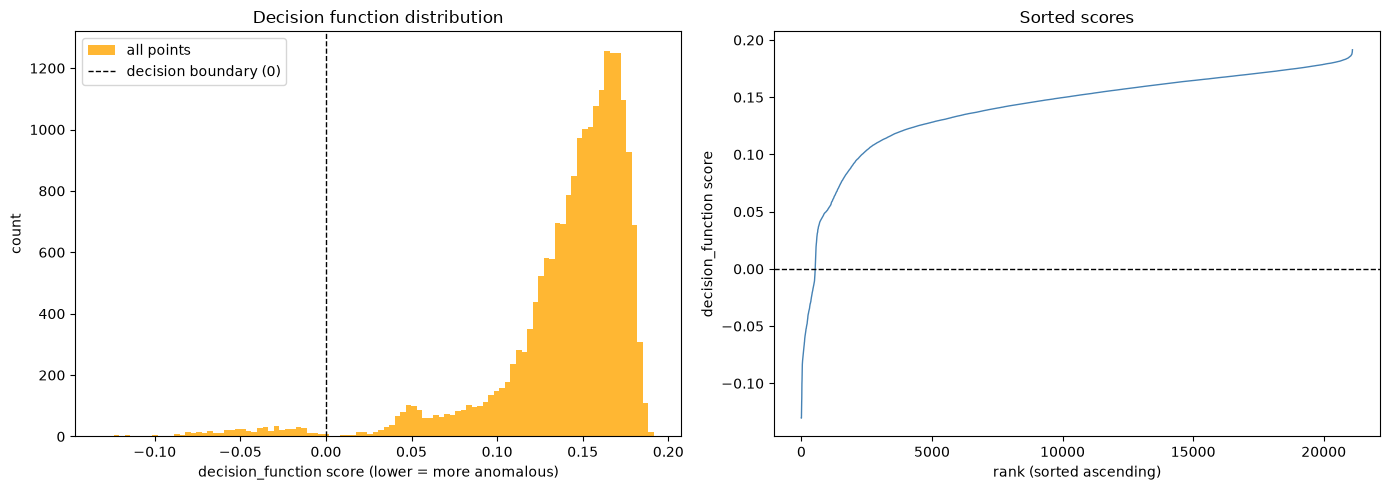

n points               : 21102
score min / max         : -0.1304 / 0.1915
score mean / std        : 0.1402 / 0.0427
   0.1th percentile     : -0.0996  (21 points below)
   0.5th percentile     : -0.0666  (105 points below)
     1th percentile     : -0.0486  (211 points below)
     2th percentile     : -0.0198  (422 points below)
     5th percentile     : 0.0535  (1055 points below)


array([0.12840563, 0.14967193, 0.1625724 , ..., 0.14621444, 0.09510305,
       0.11665952], shape=(21102,))

In [12]:
from anomaly_detection.utils.score_diagnostics import run_diagnostics

run_diagnostics(application_model, X_application, known_anomaly_mask=None)

In [13]:
decision_scores = application_model.decision_function(X_application)

new_contamination = np.mean(decision_scores < 0.05)

new_contamination

np.float64(0.044924651691782766)

In [14]:
anomalies_df = results_df[results_df['prediction'] == -1]

anomalies_df

,hour_sin,minute_cos,day_sin,day_cos,month_sin,minute_sin,second_cos,hour_cos,deltatime,month_cos,...,version,execution_thread_id,event_record_id,correlation_activity_id,previous_event_id,event_id,entity,context,anomaly_score,prediction
53,2.588190e-01,0.309017,-0.433884,-0.900969,1.224647e-16,0.951057,0.994522,-0.965926,0 days 00:00:32.624331,-1.0,...,0.0,0.0,2899088,None,16394,16384,NaN,2126-05-19T11:12:59Z | RulesEngine,-0.587793,-1
137,2.588190e-01,-0.309017,-0.433884,-0.900969,1.224647e-16,-0.951057,0.994522,-0.965926,0 days 00:00:32.381811,-1.0,...,0.0,0.0,2899172,None,16394,16384,NaN,2126-05-19T11:42:59Z | RulesEngine,-0.581860,-1
223,1.224647e-16,0.309017,-0.433884,-0.900969,1.224647e-16,0.951057,0.994522,-1.000000,0 days 00:00:32.627894,-1.0,...,0.0,0.0,2899258,None,16394,16384,NaN,2126-05-19T12:12:59Z | RulesEngine,-0.620978,-1
285,1.224647e-16,-0.913545,-0.433884,-0.900969,1.224647e-16,-0.406737,-0.994522,-1.000000,0 days 00:00:28.240179,-1.0,...,NaN,NaN,2899320,None,4,4098,NaN,ordinateur | mrxsmb10 | GPO - Désactiver le pr...,-0.571181,-1
308,1.224647e-16,-0.309017,-0.433884,-0.900969,1.224647e-16,-0.951057,0.994522,-1.000000,0 days 00:00:32.260025,-1.0,...,0.0,0.0,2899343,None,16394,16384,NaN,2126-05-19T12:42:59Z | RulesEngine,-0.572082,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20811,8.660254e-01,0.406737,0.974928,-0.222521,1.224647e-16,0.913545,-0.104528,-0.500000,0 days 00:01:40.111408,-1.0,...,NaN,NaN,2919846,None,4,4098,NaN,ordinateur | mrxsmb10 | GPO - Désactiver le pr...,-0.588359,-1
20818,8.660254e-01,0.309017,0.974928,-0.222521,1.224647e-16,0.951057,0.951057,-0.500000,0 days 00:00:34.241707,-1.0,...,0.0,0.0,2919853,None,16394,16384,NaN,2126-05-24T08:12:57Z | RulesEngine,-0.560186,-1
20904,8.660254e-01,-0.309017,0.974928,-0.222521,1.224647e-16,-0.951057,0.866025,-0.500000,0 days 00:00:32.450893,-1.0,...,0.0,0.0,2919939,None,16394,16384,NaN,2126-05-24T08:42:55Z | RulesEngine,-0.610256,-1
20992,7.071068e-01,0.207912,0.974928,-0.222521,1.224647e-16,0.978148,0.669131,-0.707107,0 days 00:00:44.093511,-1.0,...,0.0,0.0,2920027,None,16394,16384,NaN,2126-05-24T09:13:08Z | RulesEngine,-0.635056,-1


In [15]:
anomalies_df['event_id'].value_counts()

event_id
16384    251
4         81
1001      57
4098      54
64        45
1000      40
Name: count, dtype: int64

In [20]:
# Extract samples from each anomalous event ID
def pick_application_samples(n_samples_per_event):
    for event_id, group in anomalies_df.groupby("event_id"):
        print(f"\n{'=' * 60}")
        print(f"EventID {event_id}  --  {len(group)} anomalous rows")
        
        idx_min, idx_max = group.index.min(), group.index.max()
        idx_span = idx_max - idx_min
        print(f"row-index range: {idx_min} -> {idx_max}  (span: {idx_span})")
        print(f"{'=' * 60}")
    
        sample = group.sort_values("anomaly_score").head(n_samples_per_event)
    
        for _, row in sample.iterrows():
            print(f"\n  event_record_id: {row['event_record_id']}")
            print(f"  anomaly_score:    {row['anomaly_score']:.4f}")
 
            for col in [
                "event_id",
                "previous_event_id",
                "event_id_frequency",
                "version",
                "correlation_activity_id",
                "execution_thread_id",
            ]:
                if col in row and pd.notna(row[col]):
                    val = str(row[col])[:300]
                    print(f"  {col:<16}: {val}")
            
            if "context" in row:
                print(f"  context:          {str(row['context'])[:300]}")
            if "entity" in row:
                print(f"  entity:           {row['entity']}")
 

In [21]:
from contextlib import redirect_stdout

with open(output_path / 'anomalous_samples.txt', 'w') as f:
    with redirect_stdout(f):
        pick_application_samples(5)